# Section 5.2

## Example 5.2.1

In [ ]:
t = [0, 0.55, 0.7, 1]

In [ ]:
using Plots, FNCFunctions, LaTeXStrings
theme(:dark); default(thickness_scaling=1.2)
plt = plot(layout=(4, 1),  legend=false, xlabel=L"x",  ylims=[-0.1, 1.1],  ytick=[])
for k in 0:3
    Hₖ = FNC.hatfun(t, k)
    plot!(Hₖ, 0, 1, subplot=k + 1)
    scatter!(t, Hₖ.(t), m=3, subplot=k + 1)
    annotate!(t[k+1], 0.25, text(latexstring("H_$k"), 14, :lightblue), subplot=k+1)
end
plt

## Example 5.2.2

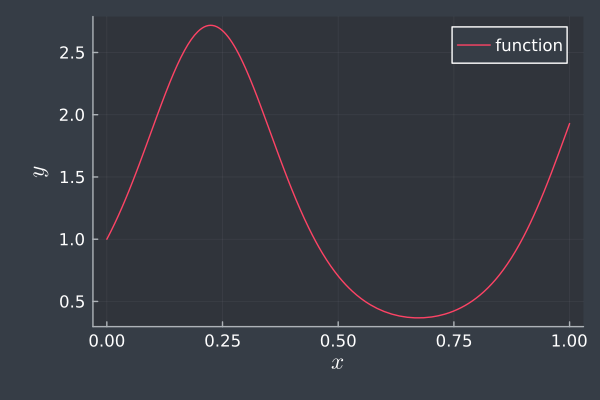

In [22]:
using Plots, LaTeXStrings
theme(:dark);  default(thickness_scaling=1.4)
f(x) = exp(sin(7x))
plot(f, 0, 1, label="function", xlabel=L"x", ylabel=L"y")

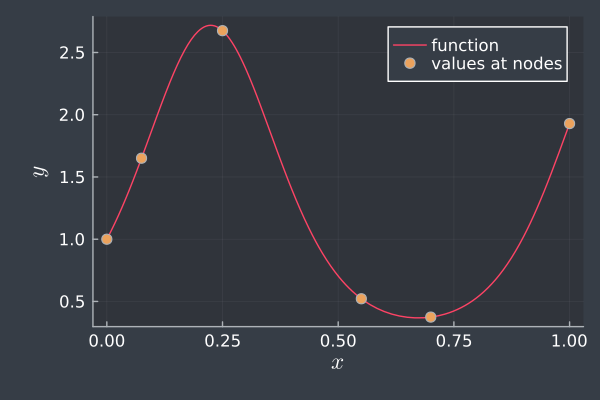

In [23]:
t = [0, 0.075, 0.25, 0.55, 0.7, 1]    # nodes
y = f.(t)                             # function values
scatter!(t, y, label="values at nodes")

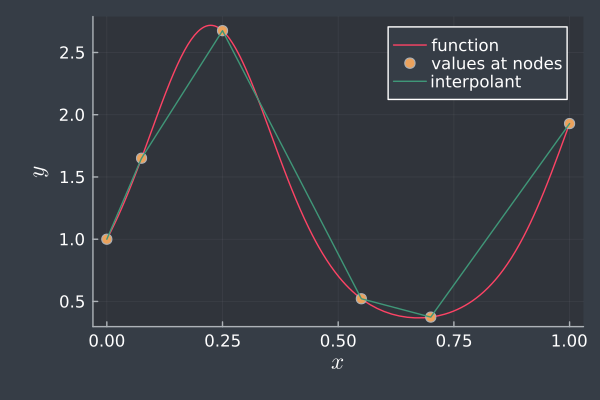

In [24]:
using FNCFunctions

p = FNC.plinterp(t, y)
plot!(p, 0, 1, label="interpolant")

## Example 5.2.3

error in PL interpolation with spacing $h$ is $O(h^2)$

In [25]:
using FNCFunctions, PrettyTables

f(x) = exp(sin(7x))
x = range(0, 1, 10001)   # sample the error at many points
n = @. round(Int, 10^(1:0.25:3.5))
maxerr = zeros(length(n))
for (k, n) in enumerate(n)
    t = (0:n) / n    # interpolation nodes
    p = FNC.plinterp(t, f.(t))
    err = @. f(x) - p(x)
    maxerr[k] = maximum(abs, err)
end

In [26]:
pretty_table((; n, maxerr); column_labels=["n", "max-norm error"], backend=:html)

n,max-norm error
10,0.150471
18,0.0476161
32,0.0160382
56,0.00530149
100,0.00166421
178,0.000525091
316,0.0001667
562,5.2703e-5
1000,1.66494e-5
1778,5.26491e-6


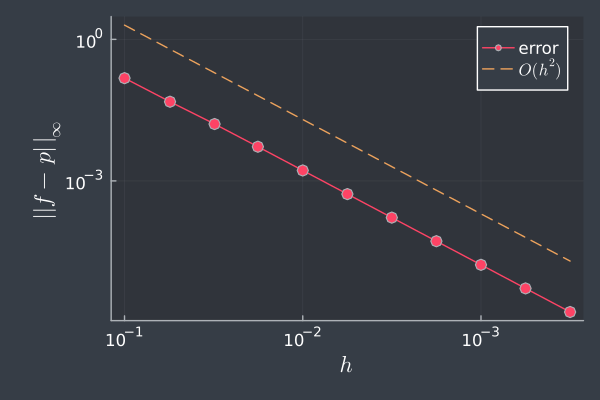

In [27]:
using Plots, LaTeXStrings
theme(:dark); default(thickness_scaling=1.4)

h = @. 1 / n
order2 = @. 2 * (h / h[1])^2

plot(h, maxerr, m=:o, label="error", xflip=true)
plot!(h, order2; l=:dash,  label=L"O(h^2)",
    xaxis=(:log10, L"h"),  yaxis=(:log10, L"|| f-p\, ||_\infty"))